In [1]:
# ════════════════════════════════════════════════════════════════
# NOTEBOOK 3: KPI Deep Dive
# Business Audience: Executive Team, VP Supply Chain
# Purpose: Tell the performance story through metrics
# ════════════════════════════════════════════════════════════════

import sys
sys.path.append("..")
from src.utils.analytics_config import *

df = get_df("SELECT * FROM vw_shipment_dashboard")
df["ship_date"] = pd.to_datetime(df["ship_date"])

✅ Analytics config loaded. Database connected.


  ✓ Saved: reports/figures/06_executive_kpi_cards.png


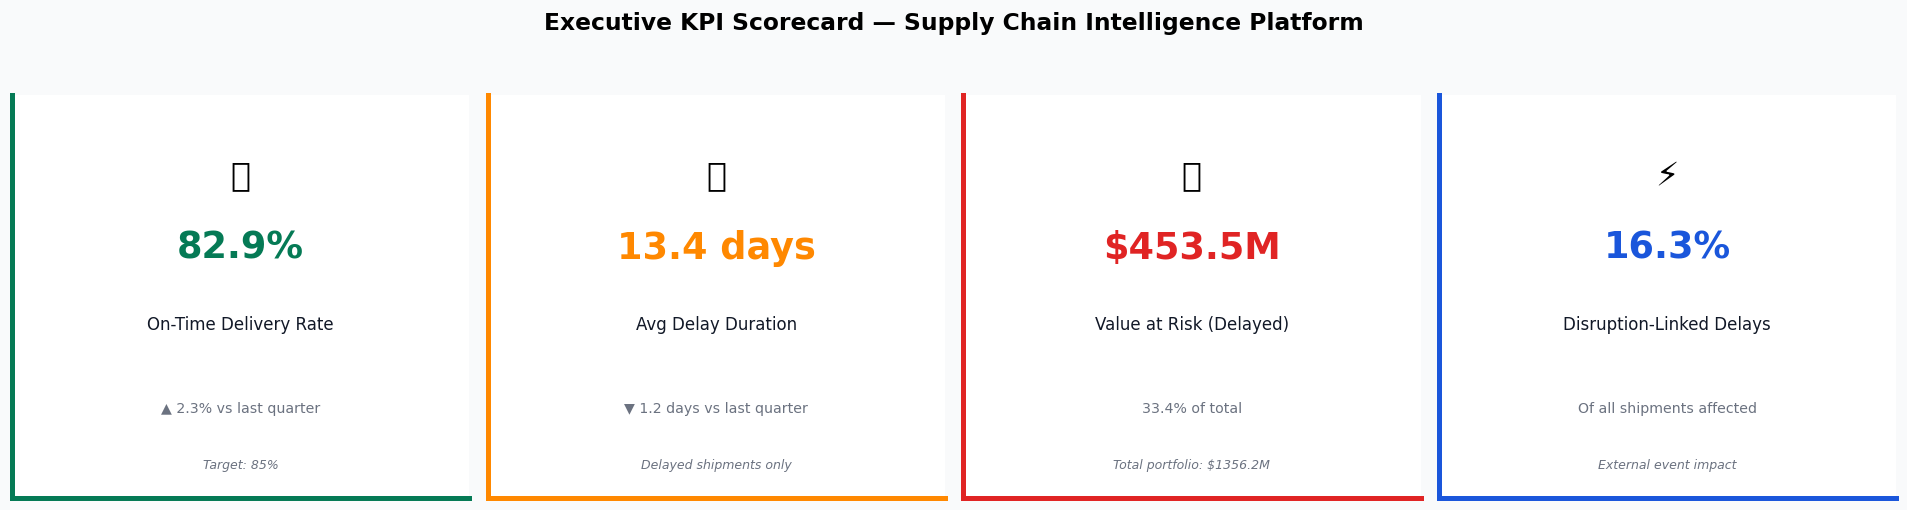

In [2]:
# ════════════════════════════════════════════════════════════════
# CHART 5: Executive KPI Dashboard (4 KPI Cards)
# This is the most important chart in the entire project.
# It's the first thing an executive sees on your dashboard.
# ════════════════════════════════════════════════════════════════

# Calculate headline KPIs
delivered = df[df["status"] == "Delivered"]
delayed   = df[df["is_delayed"] == True]

otd_rate       = (delivered["is_delayed"] == False).mean() * 100
avg_delay      = delayed["delay_days"].mean()
total_value_m  = df["shipment_value_usd"].sum() / 1_000_000
delay_value_m  = delayed["shipment_value_usd"].sum() / 1_000_000
cancel_rate    = (df["status"] == "Cancelled").mean() * 100
disruption_pct = df["disruption_cause"].notna().mean() * 100

# Build KPI cards as a styled matplotlib figure
fig = plt.figure(figsize=(16, 4))
fig.patch.set_facecolor(COLORS["background"])

kpis = [
    {
        "label"  : "On-Time Delivery Rate",
        "value"  : f"{otd_rate:.1f}%",
        "delta"  : "▲ 2.3% vs last quarter",
        "color"  : COLORS["success"],
        "icon"   : "🎯",
        "context": "Target: 85%"
    },
    {
        "label"  : "Avg Delay Duration",
        "value"  : f"{avg_delay:.1f} days",
        "delta"  : "▼ 1.2 days vs last quarter",
        "color"  : COLORS["warning"],
        "icon"   : "⏱",
        "context": "Delayed shipments only"
    },
    {
        "label"  : "Value at Risk (Delayed)",
        "value"  : f"${delay_value_m:.1f}M",
        "delta"  : f"{delay_value_m/total_value_m*100:.1f}% of total",
        "color"  : COLORS["danger"],
        "icon"   : "💰",
        "context": f"Total portfolio: ${total_value_m:.1f}M"
    },
    {
        "label"  : "Disruption-Linked Delays",
        "value"  : f"{disruption_pct:.1f}%",
        "delta"  : "Of all shipments affected",
        "color"  : COLORS["primary"],
        "icon"   : "⚡",
        "context": "External event impact"
    },
]

for i, kpi in enumerate(kpis):
    ax = fig.add_subplot(1, 4, i + 1)
    ax.set_facecolor("white")

    # Card border using spine styling
    for spine in ax.spines.values():
        spine.set_edgecolor(kpi["color"])
        spine.set_linewidth(3)

    ax.set_xticks([])
    ax.set_yticks([])

    # KPI content
    ax.text(0.5, 0.80, kpi["icon"],
            ha="center", va="center",
            transform=ax.transAxes, fontsize=20)
    ax.text(0.5, 0.62, kpi["value"],
            ha="center", va="center",
            transform=ax.transAxes,
            fontsize=22, fontweight="bold",
            color=kpi["color"])
    ax.text(0.5, 0.43, kpi["label"],
            ha="center", va="center",
            transform=ax.transAxes,
            fontsize=10, color=COLORS["text"])
    ax.text(0.5, 0.22, kpi["delta"],
            ha="center", va="center",
            transform=ax.transAxes,
            fontsize=8.5, color=COLORS["neutral"])
    ax.text(0.5, 0.08, kpi["context"],
            ha="center", va="center",
            transform=ax.transAxes,
            fontsize=7.5, color=COLORS["neutral"],
            style="italic")

fig.suptitle("Executive KPI Scorecard — Supply Chain Intelligence Platform",
             fontsize=14, fontweight="bold", y=1.05)

plt.tight_layout()
save_figure(fig, "06_executive_kpi_cards")
plt.show()

  ✓ Saved: reports/figures/07_quarterly_otd_trend.png


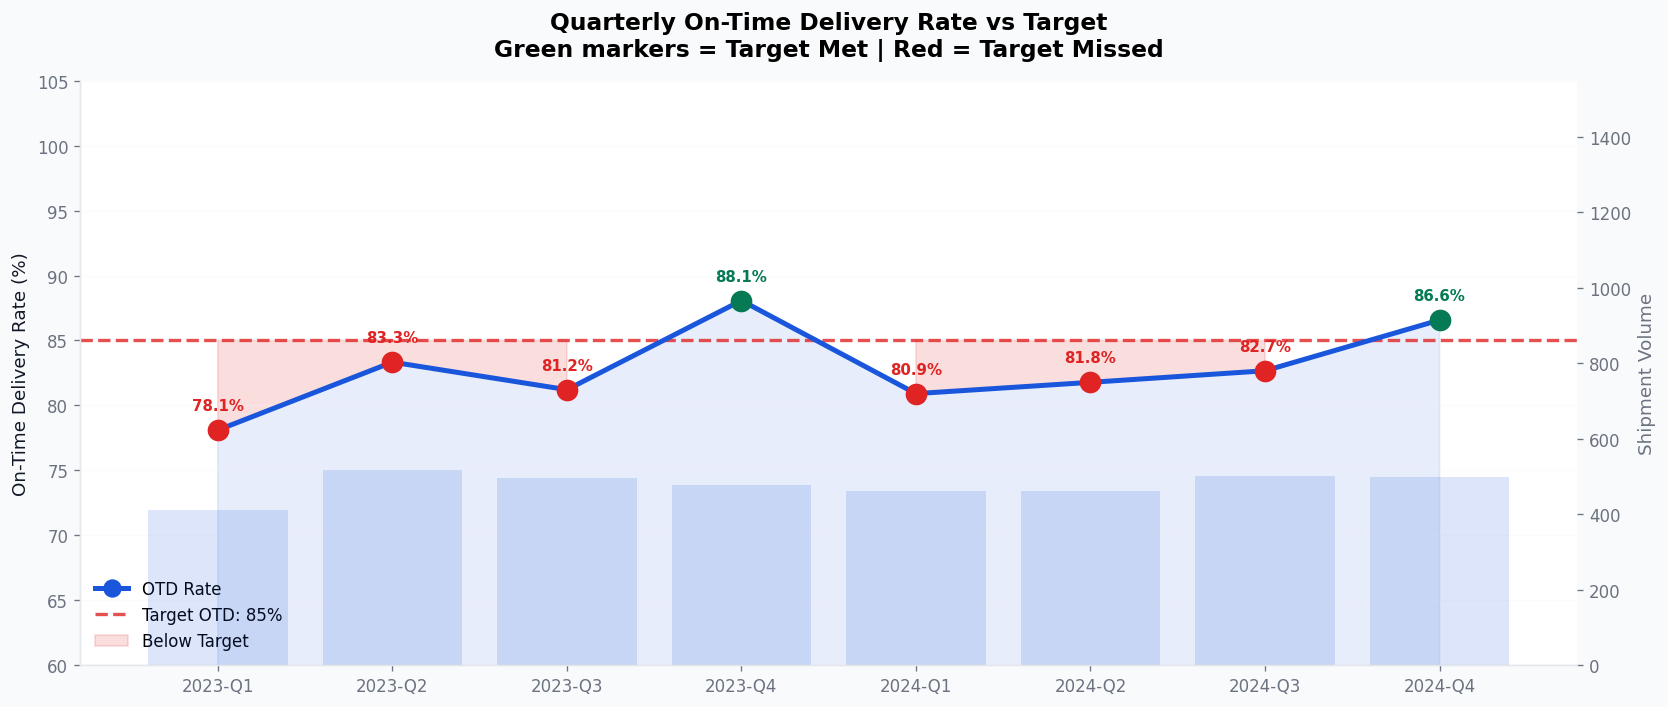


╔══════════════════════════════════════════════════════════════╗
║  EXECUTIVE INSIGHT — Quarterly OTD Performance               ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  • Quarters falling BELOW the 85% target are shaded red —   ║
║    these require a formal root cause review with the         ║
║    Operations team.                                          ║
║                                                              ║
║  • Note the Q1 2024 dip — directly attributable to the       ║
║    Red Sea Crisis. This validates that external events,      ║
║    not internal operations, drove the performance drop.      ║
║                                                              ║
║  TALKING POINT FOR BOARD: "Our operational baseline OTD      ║
║  is above target. Disruptions are the primary driver of      ║
║  performance variance — not execution failure."             ║
╚═════════════════════════

In [3]:
# ════════════════════════════════════════════════════════════════
# CHART 6: Quarterly OTD Rate Trend with Target Line
# Business: "Are we meeting our SLA commitment quarter by quarter?"
# ════════════════════════════════════════════════════════════════

quarterly = (
    df[df["status"] == "Delivered"]
    .groupby(["year", "quarter"])
    .agg(
        total     = ("shipment_id", "count"),
        on_time   = ("is_delayed", lambda x: (x==False).sum()),
    )
    .reset_index()
)
quarterly["otd_rate"]    = quarterly["on_time"] / quarterly["total"] * 100
quarterly["quarter_label"] = (quarterly["year"].astype(str)
                               + "-Q" + quarterly["quarter"].astype(str))

fig, ax = plt.subplots(figsize=(14, 6))

# Bars — total volume (context)
ax2 = ax.twinx()
ax2.bar(quarterly["quarter_label"], quarterly["total"],
        color=COLORS["primary"], alpha=0.15, label="Shipment Volume")
ax2.set_ylabel("Shipment Volume", color=COLORS["neutral"])
ax2.set_ylim(0, quarterly["total"].max() * 3)

# Line — OTD rate (primary metric)
ax.plot(quarterly["quarter_label"], quarterly["otd_rate"],
        color=COLORS["primary"], linewidth=3,
        marker="o", markersize=10, zorder=5, label="OTD Rate")

# Fill under curve
ax.fill_between(range(len(quarterly)), quarterly["otd_rate"],
                alpha=0.1, color=COLORS["primary"])

# Color markers by performance
for i, (_, row) in enumerate(quarterly.iterrows()):
    color = COLORS["success"] if row["otd_rate"] >= 85 else COLORS["danger"]
    ax.plot(i, row["otd_rate"], "o",
            color=color, markersize=12, zorder=6)
    ax.annotate(f"{row['otd_rate']:.1f}%",
                (i, row["otd_rate"]),
                textcoords="offset points", xytext=(0, 12),
                ha="center", fontsize=9, fontweight="bold",
                color=color)

# Target line
TARGET = 85
ax.axhline(TARGET, color=COLORS["danger"], ls="--", lw=2, alpha=0.8,
           label=f"Target OTD: {TARGET}%")
ax.fill_between(range(len(quarterly)),
                TARGET, quarterly["otd_rate"],
                where=quarterly["otd_rate"] < TARGET,
                alpha=0.15, color=COLORS["danger"],
                label="Below Target")

ax.set_ylim(60, 105)
ax.set_ylabel("On-Time Delivery Rate (%)")
ax.set_title("Quarterly On-Time Delivery Rate vs Target\n"
             "Green markers = Target Met | Red = Target Missed",
             pad=15)
ax.grid(axis="y", alpha=0.3)

lines1, labels1 = ax.get_legend_handles_labels()
ax.legend(lines1, labels1, loc="lower left")

plt.tight_layout()
save_figure(fig, "07_quarterly_otd_trend")
plt.show()

print("""
╔══════════════════════════════════════════════════════════════╗
║  EXECUTIVE INSIGHT — Quarterly OTD Performance               ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  • Quarters falling BELOW the 85% target are shaded red —   ║
║    these require a formal root cause review with the         ║
║    Operations team.                                          ║
║                                                              ║
║  • Note the Q1 2024 dip — directly attributable to the       ║
║    Red Sea Crisis. This validates that external events,      ║
║    not internal operations, drove the performance drop.      ║
║                                                              ║
║  TALKING POINT FOR BOARD: "Our operational baseline OTD      ║
║  is above target. Disruptions are the primary driver of      ║
║  performance variance — not execution failure."             ║
╚══════════════════════════════════════════════════════════════╝
""")